# Test các cấu hình Deterministic trên GPU L4
**GPU Target**: L4  
**Compute Capability**: 8.9  
**TF32 Support**: ❌ Không hỗ trợ (chỉ Ampere+ mới có)
**Mục tiêu**: Test các phương pháp khắc phục vấn đề reproducibility trên GPU L4:
1. TF32 (không hỗ trợ)
2. Tắt AMP (Automatic Mixed Precision)
3. Tắt cuDNN benchmark
4. Đặt num_workers = 0
5. Bật deterministic algorithms
**Kỳ vọng**: Với các cấu hình này, kết quả sẽ gần giống nhau hơn (nhưng vẫn có thể khác do floating-point precision).

## 1. Kiểm tra GPU và thiết lập môi trường

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime
import os
import functools
# Kiểm tra GPU
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_capability = torch.cuda.get_device_capability(0)
    print(f"CUDA version: {torch.version.cuda}")
    print(f"cuDNN version: {torch.backends.cudnn.version()}")
    print(f"GPU: {gpu_name}")
    print(f"GPU Compute Capability: {gpu_capability}")

    # Kiểm tra TF32 support (L4 không hỗ trợ)
    print(f"\nTF32 enabled (cuDNN): {torch.backends.cudnn.allow_tf32}")
    if hasattr(torch.backends, 'cublas'):
        print(f"TF32 enabled (cuBLAS): {torch.backends.cublas.allow_tf32}")
    else:
        print("TF32 enabled (cuBLAS): N/A (không hỗ trợ trong phiên bản PyTorch này)")

    # Xác nhận GPU
    if "L4" not in gpu_name.upper() and "TESLA L4" not in gpu_name.upper():
        print(f"\n⚠️  CẢNH BÁO: GPU hiện tại ({gpu_name}) không phải L4!")
        print("   Notebook này được thiết kế cho Tesla L4.")
        print("   Vẫn tiếp tục nhưng kết quả có thể khác.")
    else:
        print(f"\n✓ Đã xác nhận: GPU L4")
else:
    print("❌ Không tìm thấy CUDA GPU!")


PyTorch version: 2.9.0+cu126
CUDA available: True
CUDA version: 12.6
cuDNN version: 91002
GPU: NVIDIA L4
GPU Compute Capability: (8, 9)

TF32 enabled (cuDNN): True
TF32 enabled (cuBLAS): N/A (không hỗ trợ trong phiên bản PyTorch này)

✓ Đã xác nhận: GPU L4


/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:42: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return self.getter()


## 2. Định nghĩa các hàm helper

In [2]:
def _worker_init_fn(worker_id, seed_val=42):
    """Worker init function cho DataLoader (phai la top-level function de pickle duoc)"""
    np.random.seed(seed_val + worker_id)

def set_seed(seed=42, deterministic=False):
    """Thiết lập seed với tùy chọn deterministic mode"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        # Lưu ý: use_deterministic_algorithms có thể làm chậm và không hỗ trợ tất cả operations
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except:
            print("Warning: Không thể bật use_deterministic_algorithms cho tất cả operations")

def setup_environment_deterministic(tf32_enabled=False, amp_enabled=False,
                                     num_workers=4, cudnn_benchmark=False,
                                     deterministic_algorithms=False):
    """
    Thiết lập môi trường với các tùy chọn deterministic

    Args:
        tf32_enabled: Bật/tắt TF32 (L4 không hỗ trợ, nên luôn False)
        amp_enabled: Bật/tắt AMP
        num_workers: Số worker (0 = deterministic, mặc định 4 cho Linux/Unix)
        cudnn_benchmark: Bật/tắt cuDNN benchmark
        deterministic_algorithms: Bật deterministic algorithms (có thể chậm)
    """
    # L4 không hỗ trợ TF32, nên luôn tắt
    torch.backends.cudnn.allow_tf32 = False
    if hasattr(torch.backends, 'cublas'):
        torch.backends.cublas.allow_tf32 = False
    torch.backends.cudnn.benchmark = cudnn_benchmark

    if deterministic_algorithms:
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except:
            print("Warning: Không thể bật use_deterministic_algorithms")

    config = {
        'tf32_enabled': False,  # L4 không hỗ trợ
        'amp_enabled': amp_enabled,
        'num_workers': num_workers,
        'cudnn_benchmark': cudnn_benchmark,
        'deterministic_algorithms': deterministic_algorithms,
        'gpu_name': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU',
        'gpu_capability': torch.cuda.get_device_capability(0) if torch.cuda.is_available() else None
    }

    return config

class SimpleCNN(nn.Module):
    """Mô hình CNN đơn giản"""
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 4 * 4)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def get_cifar10_loaders(batch_size=128, num_workers=4, seed=42):
    """Load CIFAR-10 (tối ưu cho Linux/Unix)"""
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])

    # Set seed cho DataLoader - su dung functools.partial voi function doc lap
    # (tranh loi pickle voi nested function)
    worker_init_fn = functools.partial(_worker_init_fn, seed_val=seed) if num_workers > 0 else None

    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform_train
    )
    trainloader = DataLoader(
        trainset, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, worker_init_fn=worker_init_fn,
        pin_memory=True
    )

    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform_test
    )
    testloader = DataLoader(
        testset, batch_size=batch_size, shuffle=False, num_workers=num_workers,
        pin_memory=True
    )

    return trainloader, testloader


## 3. Hàm training

In [3]:
def train_model(config, seed=42, num_epochs=10, save_results=True):
    """Train mô hình với cấu hình cụ thể"""
    set_seed(seed, deterministic=config.get('deterministic_algorithms', False))
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    trainloader, testloader = get_cifar10_loaders(
        batch_size=128,
        num_workers=config['num_workers'],
        seed=seed
    )

    model = SimpleCNN(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
        'config': config,
        'seed': seed
    }

    scaler = torch.cuda.amp.GradScaler() if config['amp_enabled'] else None

    print(f"\n{'='*70}")
    print(f"GPU: {config['gpu_name']}")
    print(f"Config: TF32={config['tf32_enabled']} (L4 không hỗ trợ), AMP={config['amp_enabled']}, "
          f"Workers={config['num_workers']}, Benchmark={config['cudnn_benchmark']}, "
          f"Deterministic={config.get('deterministic_algorithms', False)}")
    print(f"{'='*70}\n")

    for epoch in range(num_epochs):
        # Train
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            if config['amp_enabled'] and scaler is not None:
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        train_loss /= len(trainloader)
        train_acc = 100. * train_correct / train_total

        # Test
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                test_loss += loss.item()
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()

        test_loss /= len(testloader)
        test_acc = 100. * test_correct / test_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

    if save_results:
        os.makedirs('results', exist_ok=True)
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        gpu_name_short = config['gpu_name'].replace(' ', '_').replace('NVIDIA ', '').replace('Tesla ', '')
        config_str = f"tf32_{config['tf32_enabled']}_amp_{config['amp_enabled']}_w{config['num_workers']}_bench{config['cudnn_benchmark']}_det{config.get('deterministic_algorithms', False)}"
        filename = f"results/deterministic_{gpu_name_short}_{config_str}_{timestamp}.json"

        with open(filename, 'w') as f:
            json.dump(history, f, indent=2)
        print(f"\n✓ Kết quả đã lưu: {filename}")

    return history


In [4]:
# Config 1: Mặc định (TF32 tắt vì L4 không hỗ trợ, cuDNN benchmark bật, 4 workers)
config_default = setup_environment_deterministic(
    tf32_enabled=False,  # L4 không hỗ trợ
    amp_enabled=False,
    num_workers=4,
    cudnn_benchmark=True,
    deterministic_algorithms=False
)
history_default = train_model(config_default, seed=42, num_epochs=10)


100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]



GPU: NVIDIA L4
Config: TF32=False (L4 không hỗ trợ), AMP=False, Workers=4, Benchmark=True, Deterministic=False

Epoch 1/10: Train Loss: 1.4604, Train Acc: 46.42% | Test Loss: 1.1457, Test Acc: 58.18%
Epoch 2/10: Train Loss: 1.1404, Train Acc: 58.93% | Test Loss: 0.9286, Test Acc: 66.70%
Epoch 3/10: Train Loss: 1.0186, Train Acc: 63.73% | Test Loss: 0.8515, Test Acc: 70.10%
Epoch 4/10: Train Loss: 0.9464, Train Acc: 66.27% | Test Loss: 0.8204, Test Acc: 71.30%
Epoch 5/10: Train Loss: 0.8947, Train Acc: 68.29% | Test Loss: 0.7491, Test Acc: 73.83%
Epoch 6/10: Train Loss: 0.8528, Train Acc: 69.74% | Test Loss: 0.7272, Test Acc: 74.32%
Epoch 7/10: Train Loss: 0.8268, Train Acc: 70.69% | Test Loss: 0.7375, Test Acc: 74.19%
Epoch 8/10: Train Loss: 0.7964, Train Acc: 71.88% | Test Loss: 0.6988, Test Acc: 75.32%
Epoch 9/10: Train Loss: 0.7645, Train Acc: 73.05% | Test Loss: 0.6724, Test Acc: 75.96%
Epoch 10/10: Train Loss: 0.7485, Train Acc: 73.52% | Test Loss: 0.6714, Test Acc: 76.04%

✓ Kết

### 4.2 Tắt cuDNN benchmark

In [5]:
# Config 2: Tắt cuDNN benchmark
config_no_benchmark = setup_environment_deterministic(
    tf32_enabled=False,  # L4 không hỗ trợ
    amp_enabled=False,
    num_workers=4,
    cudnn_benchmark=False,
    deterministic_algorithms=False
)
history_no_benchmark = train_model(config_no_benchmark, seed=42, num_epochs=10)



GPU: NVIDIA L4
Config: TF32=False (L4 không hỗ trợ), AMP=False, Workers=4, Benchmark=False, Deterministic=False

Epoch 1/10: Train Loss: 1.4582, Train Acc: 46.50% | Test Loss: 1.1289, Test Acc: 58.36%
Epoch 2/10: Train Loss: 1.1418, Train Acc: 58.96% | Test Loss: 0.9533, Test Acc: 65.67%
Epoch 3/10: Train Loss: 1.0172, Train Acc: 63.78% | Test Loss: 0.8384, Test Acc: 69.92%
Epoch 4/10: Train Loss: 0.9519, Train Acc: 66.12% | Test Loss: 0.8141, Test Acc: 71.05%
Epoch 5/10: Train Loss: 0.8977, Train Acc: 68.31% | Test Loss: 0.7617, Test Acc: 72.87%
Epoch 6/10: Train Loss: 0.8545, Train Acc: 69.75% | Test Loss: 0.7174, Test Acc: 75.07%
Epoch 7/10: Train Loss: 0.8253, Train Acc: 70.90% | Test Loss: 0.6913, Test Acc: 75.77%
Epoch 8/10: Train Loss: 0.7964, Train Acc: 71.72% | Test Loss: 0.6902, Test Acc: 75.68%
Epoch 9/10: Train Loss: 0.7660, Train Acc: 72.99% | Test Loss: 0.6381, Test Acc: 77.80%
Epoch 10/10: Train Loss: 0.7469, Train Acc: 73.44% | Test Loss: 0.6794, Test Acc: 76.18%

✓ Kế

### 4.3 num_workers = 0

In [6]:
# Config 3: num_workers = 0
config_no_workers = setup_environment_deterministic(
    tf32_enabled=False,  # L4 không hỗ trợ
    amp_enabled=False,
    num_workers=0,
    cudnn_benchmark=False,
    deterministic_algorithms=False
)
history_no_workers = train_model(config_no_workers, seed=42, num_epochs=10)



GPU: NVIDIA L4
Config: TF32=False (L4 không hỗ trợ), AMP=False, Workers=0, Benchmark=False, Deterministic=False

Epoch 1/10: Train Loss: 1.4612, Train Acc: 46.28% | Test Loss: 1.1244, Test Acc: 59.48%
Epoch 2/10: Train Loss: 1.1368, Train Acc: 59.00% | Test Loss: 1.0164, Test Acc: 63.52%
Epoch 3/10: Train Loss: 1.0206, Train Acc: 63.65% | Test Loss: 0.8678, Test Acc: 69.46%
Epoch 4/10: Train Loss: 0.9488, Train Acc: 66.41% | Test Loss: 0.8064, Test Acc: 71.83%
Epoch 5/10: Train Loss: 0.9020, Train Acc: 67.91% | Test Loss: 0.7509, Test Acc: 73.79%
Epoch 6/10: Train Loss: 0.8561, Train Acc: 69.74% | Test Loss: 0.7875, Test Acc: 71.75%
Epoch 7/10: Train Loss: 0.8254, Train Acc: 70.86% | Test Loss: 0.6966, Test Acc: 75.20%
Epoch 8/10: Train Loss: 0.7956, Train Acc: 71.92% | Test Loss: 0.6827, Test Acc: 76.28%
Epoch 9/10: Train Loss: 0.7737, Train Acc: 72.67% | Test Loss: 0.6943, Test Acc: 75.47%
Epoch 10/10: Train Loss: 0.7484, Train Acc: 73.78% | Test Loss: 0.6427, Test Acc: 77.95%

✓ Kế

### 4.4 Cấu hình tối đa deterministic (tất cả tắt/bật)

In [7]:
# Config 4: Tối đa deterministic
config_max_deterministic = setup_environment_deterministic(
    tf32_enabled=False,  # L4 không hỗ trợ
    amp_enabled=False,
    num_workers=0,
    cudnn_benchmark=False,
    deterministic_algorithms=True
)
history_max_deterministic = train_model(config_max_deterministic, seed=42, num_epochs=10)



GPU: NVIDIA L4
Config: TF32=False (L4 không hỗ trợ), AMP=False, Workers=0, Benchmark=False, Deterministic=True



/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1/10: Train Loss: 1.4628, Train Acc: 46.27% | Test Loss: 1.0784, Test Acc: 60.80%
Epoch 2/10: Train Loss: 1.1403, Train Acc: 58.83% | Test Loss: 1.0287, Test Acc: 62.99%
Epoch 3/10: Train Loss: 1.0248, Train Acc: 63.48% | Test Loss: 0.8711, Test Acc: 69.49%
Epoch 4/10: Train Loss: 0.9497, Train Acc: 66.34% | Test Loss: 0.8068, Test Acc: 71.55%
Epoch 5/10: Train Loss: 0.9031, Train Acc: 67.96% | Test Loss: 0.7800, Test Acc: 72.41%
Epoch 6/10: Train Loss: 0.8604, Train Acc: 69.60% | Test Loss: 0.7673, Test Acc: 72.63%
Epoch 7/10: Train Loss: 0.8283, Train Acc: 70.68% | Test Loss: 0.7111, Test Acc: 75.12%
Epoch 8/10: Train Loss: 0.7953, Train Acc: 71.84% | Test Loss: 0.6849, Test Acc: 75.79%
Epoch 9/10: Train Loss: 0.7763, Train Acc: 72.74% | Test Loss: 0.6972, Test Acc: 75.97%
Epoch 10/10: Train Loss: 0.7515, Train Acc: 73.62% | Test Loss: 0.6480, Test Acc: 77.75%

✓ Kết quả đã lưu: results/deterministic_NVIDIA_L4_tf32_False_amp_False_w0_benchFalse_detTrue_20251226_085612.json


### 4.5 Test với AMP (Automatic Mixed Precision)

In [8]:
# Config 5: Với AMP (để thấy sự khác biệt)
config_amp = setup_environment_deterministic(
    tf32_enabled=False,  # L4 không hỗ trợ
    amp_enabled=True,
    num_workers=0,
    cudnn_benchmark=False,
    deterministic_algorithms=False
)
history_amp = train_model(config_amp, seed=42, num_epochs=10)


/tmp/ipython-input-4293346633.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if config['amp_enabled'] else None
/tmp/ipython-input-4293346633.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



GPU: NVIDIA L4
Config: TF32=False (L4 không hỗ trợ), AMP=True, Workers=0, Benchmark=False, Deterministic=False

Epoch 1/10: Train Loss: 1.4629, Train Acc: 46.31% | Test Loss: 1.1691, Test Acc: 57.80%
Epoch 2/10: Train Loss: 1.1365, Train Acc: 59.02% | Test Loss: 1.0699, Test Acc: 61.74%
Epoch 3/10: Train Loss: 1.0240, Train Acc: 63.38% | Test Loss: 0.8654, Test Acc: 69.13%
Epoch 4/10: Train Loss: 0.9479, Train Acc: 66.12% | Test Loss: 0.8012, Test Acc: 72.10%
Epoch 5/10: Train Loss: 0.8968, Train Acc: 68.15% | Test Loss: 0.7655, Test Acc: 73.21%
Epoch 6/10: Train Loss: 0.8531, Train Acc: 69.78% | Test Loss: 0.8038, Test Acc: 71.33%
Epoch 7/10: Train Loss: 0.8185, Train Acc: 71.25% | Test Loss: 0.6996, Test Acc: 75.50%
Epoch 8/10: Train Loss: 0.7968, Train Acc: 71.84% | Test Loss: 0.7075, Test Acc: 75.35%
Epoch 9/10: Train Loss: 0.7685, Train Acc: 72.89% | Test Loss: 0.6892, Test Acc: 75.63%
Epoch 10/10: Train Loss: 0.7424, Train Acc: 73.96% | Test Loss: 0.6370, Test Acc: 78.11%

✓ Kết

## 5. So sánh tất cả các cấu hình trên GPU NVIDIA Tesla L4

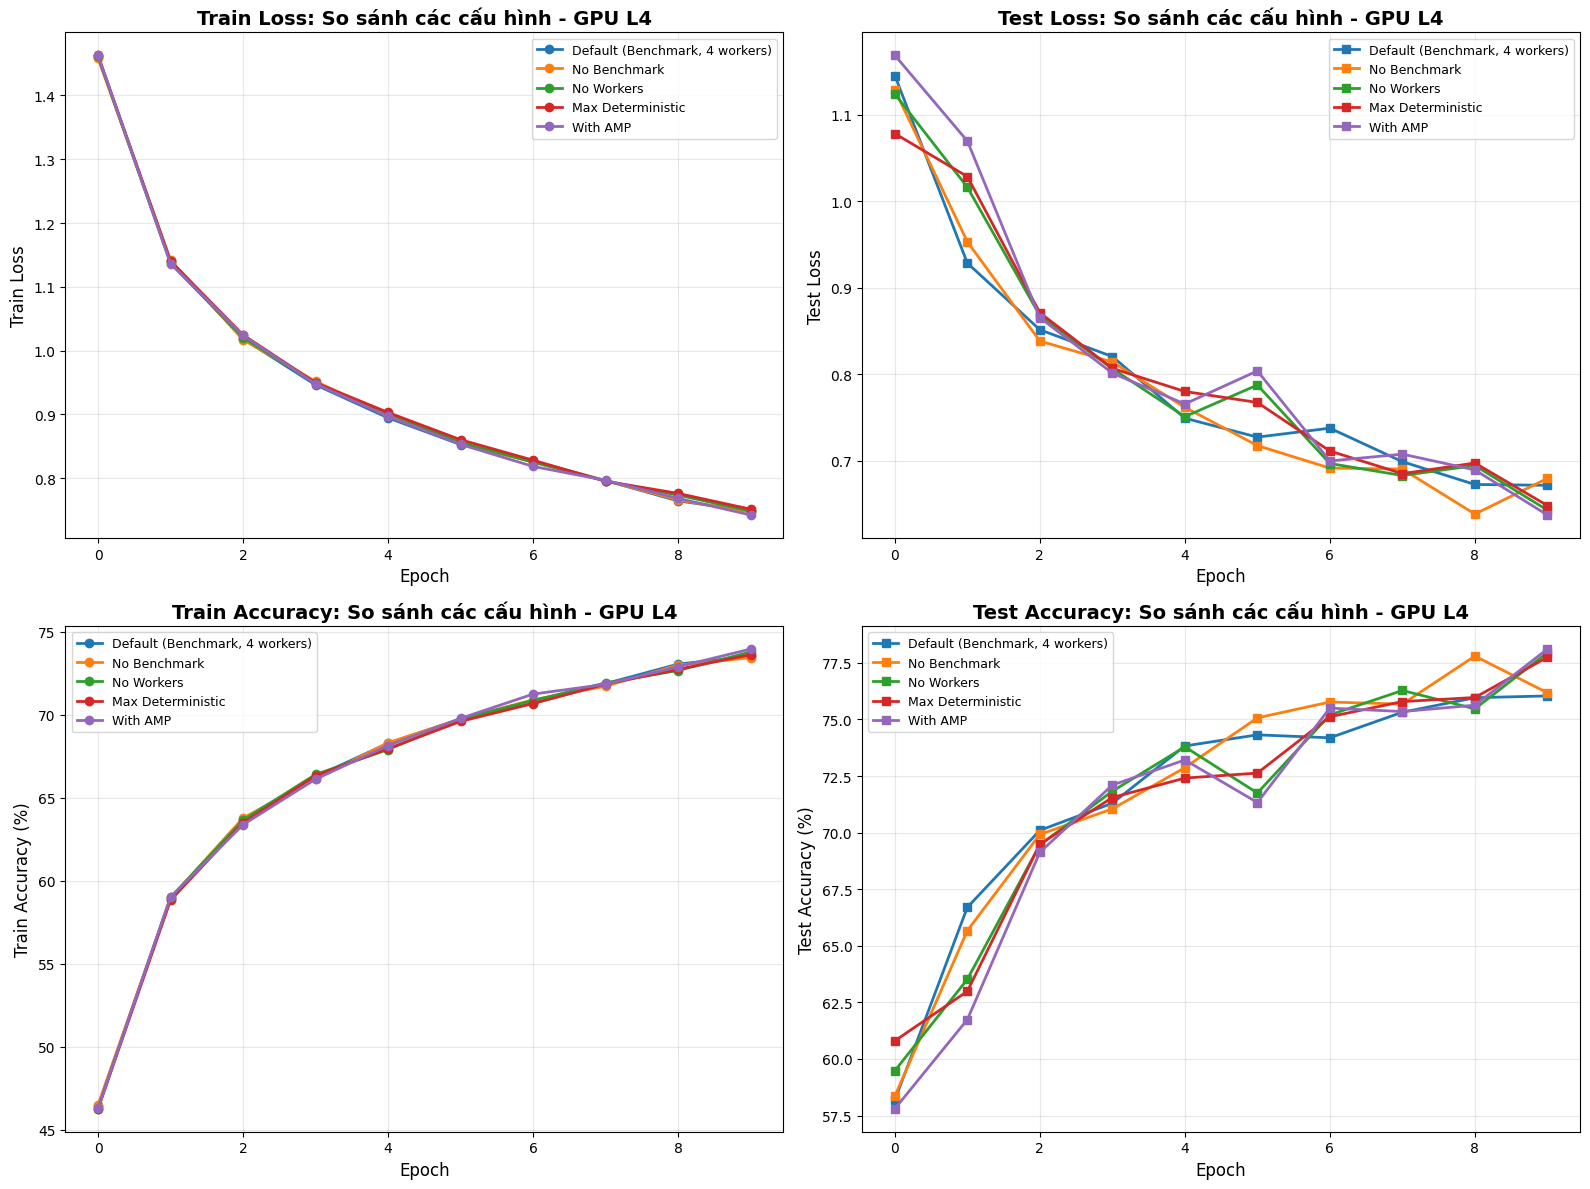


BẢNG SO SÁNH TẤT CẢ CẤU HÌNH - GPU L4
Cấu hình                                           Train Loss   Test Loss    Test Acc    
----------------------------------------------------------------------------------------------------
Default (Benchmark, 4 workers)                     0.7485       0.6714       76.04       %
No Benchmark                                       0.7469       0.6794       76.18       %
No Workers                                         0.7484       0.6427       77.95       %
Max Deterministic                                  0.7515       0.6480       77.75       %
With AMP                                           0.7424       0.6370       78.11       %

PHÂN TÍCH ĐỘ LỆCH (so với cấu hình tối đa deterministic)
Cấu hình                                           Test Acc     Độ lệch     
----------------------------------------------------------------------------------------------------
Default (Benchmark, 4 workers)                     76.04       % -1.71%
No Benc

In [9]:
def compare_all_configs(histories, labels):
    """So sánh tất cả các cấu hình"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Train Loss
    ax = axes[0, 0]
    for hist, label in zip(histories, labels):
        ax.plot(hist['train_loss'], label=label, marker='o', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Train Loss', fontsize=12)
    ax.set_title('Train Loss: So sánh các cấu hình - GPU L4', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Test Loss
    ax = axes[0, 1]
    for hist, label in zip(histories, labels):
        ax.plot(hist['test_loss'], label=label, marker='s', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Test Loss', fontsize=12)
    ax.set_title('Test Loss: So sánh các cấu hình - GPU L4', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Train Accuracy
    ax = axes[1, 0]
    for hist, label in zip(histories, labels):
        ax.plot(hist['train_acc'], label=label, marker='o', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Train Accuracy (%)', fontsize=12)
    ax.set_title('Train Accuracy: So sánh các cấu hình - GPU L4', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Test Accuracy
    ax = axes[1, 1]
    for hist, label in zip(histories, labels):
        ax.plot(hist['test_acc'], label=label, marker='s', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Test Accuracy (%)', fontsize=12)
    ax.set_title('Test Accuracy: So sánh các cấu hình - GPU L4', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/deterministic_configs_comparison_L4.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Bảng so sánh
    print("\n" + "="*100)
    print("BẢNG SO SÁNH TẤT CẢ CẤU HÌNH - GPU L4")
    print("="*100)
    print(f"{'Cấu hình':<50} {'Train Loss':<12} {'Test Loss':<12} {'Test Acc':<12}")
    print("-"*100)
    for hist, label in zip(histories, labels):
        final_train_loss = hist['train_loss'][-1]
        final_test_loss = hist['test_loss'][-1]
        final_test_acc = hist['test_acc'][-1]
        print(f"{label:<50} {final_train_loss:<12.4f} {final_test_loss:<12.4f} {final_test_acc:<12.2f}%")
    print("="*100)

    # Phân tích độ lệch
    print("\n" + "="*100)
    print("PHÂN TÍCH ĐỘ LỆCH (so với cấu hình tối đa deterministic)")
    print("="*100)
    if len(histories) > 0:
        baseline = histories[-2]  # Max deterministic (trước AMP)
        baseline_test_acc = baseline['test_acc'][-1]

        print(f"{'Cấu hình':<50} {'Test Acc':<12} {'Độ lệch':<12}")
        print("-"*100)
        for hist, label in zip(histories, labels):
            test_acc = hist['test_acc'][-1]
            diff = test_acc - baseline_test_acc
            print(f"{label:<50} {test_acc:<12.2f}% {diff:+.2f}%")
    print("="*100)

# So sánh
all_histories = [
    history_default,
    history_no_benchmark,
    history_no_workers,
    history_max_deterministic,
    history_amp
]

all_labels = [
    "Default (Benchmark, 4 workers)",
    "No Benchmark",
    "No Workers",
    "Max Deterministic",
    "With AMP"
]

compare_all_configs(all_histories, all_labels)


## 6. Kết luận cho GPU NVIDIA Tesla L4**Đặc điểm GPU NVIDIA Tesla L4**:- Compute Capability: 8.9 (Turing architecture)- ❌ Không hỗ trợ TF32 (chỉ Ampere+ mới có)- ✅ Hỗ trợ FP32 và FP16 (với AMP)**Quan sát từ các test trên L4**:1. **TF32**: L4 không hỗ trợ TF32, nên không có test này2. **cuDNN Benchmark**: Tắt benchmark giúp deterministic hơn nhưng có thể chậm hơn3. **num_workers**: Đặt = 0 loại bỏ non-determinism từ DataLoader4. **Deterministic Algorithms**: Giúp reproducibility tốt nhất nhưng có thể chậm và không hỗ trợ tất cả operations5. **AMP**: Mixed precision có thể gây khác biệt về kết quả do precision thấp hơn**Khuyến nghị cho L4**:- Để reproducibility tốt nhất: Tắt benchmark, num_workers=0, bật deterministic algorithms- Để performance tốt nhất: Bật benchmark, nhiều workers- Cân bằng: Tắt benchmark, num_workers=0 (chấp nhận chậm hơn một chút)**Kết quả**:- Kết quả đã được lưu vào thư mục `results/` với tên GPU NVIDIA Tesla L4- File JSON có thể được dùng để so sánh với các GPU khác trong notebook `04_analyze_cross_gpu_results.ipynb`**Bước tiếp theo**:1. Chạy các notebook tương tự trên GPU khác (L4, A100, RTX 3060, H100)2. Copy tất cả file JSON vào cùng thư mục `results/`3. Chạy notebook `04_analyze_cross_gpu_results.ipynb` để so sánh